## Solution with finite differences and Newton

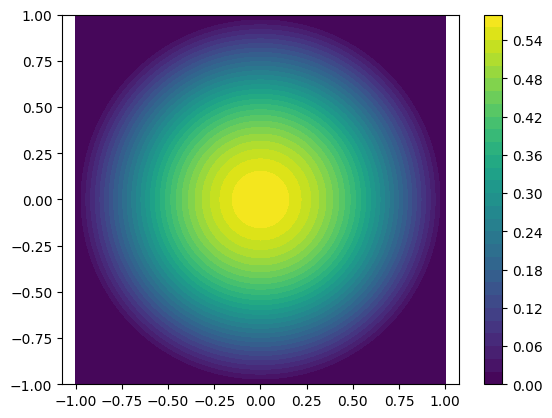

In [15]:
import numpy as np
from scipy.sparse import diags, eye, lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

N = 1000
x = np.linspace(-1, 1, N)
h = x[1]-x[0]
X, Y = np.meshgrid(x, x, indexing='ij')
interior = (X**2 + Y**2) < (1 - 1.5*h)**2   # strictly inside
idx = -np.ones((N, N), dtype=int)
idx[interior] = np.arange(interior.sum())
n = interior.sum()

A = lil_matrix((n, n))
for i in range(N):
    for j in range(N):
        k = idx[i, j]
        if k < 0: continue
        A[k, k] = -4/h**2
        for di, dj in [(1,0),(-1,0),(0,1),(0,-1)]:
            kn = idx[i+di, j+dj] if 0<=i+di<N and 0<=j+dj<N else -1
            if kn >= 0: A[k, kn] = 1/h**2

A = csr_matrix(A)
I = eye(n)

rng = np.random.default_rng(seed=42)
u = rng.uniform(0, 1, size=n) 
for _ in range(30):
    F = A @ u + 6*u - u**3
    J = A + 6*I - diags(3*u**2)
    du = spsolve(J, -F)
    u += du
    if np.linalg.norm(du) < 1e-10: break

U = np.zeros((N, N)); U[interior] = u
import matplotlib.pyplot as plt
plt.contourf(X, Y, U, 30)
plt.colorbar(); plt.axis('equal'); plt.show()

In [16]:
L2_norm = np.sqrt(np.sum(u**2) * h**2)

In [17]:
L2_norm

np.float64(0.5344490925728533)

In [ ]:
import torch

def r_func_unitBall(x):
    return 1-torch.norm(x, dim = 1)

In [6]:
a = torch.Tensor([[0,1],[0,0],[0.5,0], [0,1]])

r_func_unitBall(a)

tensor([0.0000, 1.0000, 0.5000, 0.0000])